In [29]:
# Chapter 10 Hands on ML with Scikit-Learn tf and keras

In [30]:
import tensorflow as tf
from tensorflow import keras

In [31]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_raw, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train_raw.shape)
print(X_test.shape)
print(X_train_raw.dtype)

(60000, 28, 28)
(10000, 28, 28)
uint8


In [32]:
# Preprocessing Data

# Scaling Ints to Floats 0-1
X_train, X_valid = X_train_raw[:55000] / 255.0, X_train_raw[55000:] / 255.0
y_train, y_valid = y_train[:55000], y_train[55000:]

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names[y_train[0]]




'Ankle boot'

In [35]:
# classification MLP 
model = keras.models.Sequential()
# Layer 1: Flatten layer -> converts 2D array to 1D, input shape has to be specified
model.add(keras.layers.Flatten(input_shape=[28, 28]))
# Layer 2&3: Hidden layers
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
# Layer 4: Output layer -> softmax for classification
model.add(keras.layers.Dense(10, activation='softmax'))

model.summary()
weights, biases = model.layers[1].get_weights()
print(weights)
print(biases)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

[[-0.05070924 -0.05966336  0.04268423 ...  0.02372317 -0.05326686
   0.02482764]
 [-0.06122135  0.01961033  0.03916971 ... -0.06284087 -0.07000159
  -0.00611956]
 [-0.00494817  0.0467007   0.02988401 ... -0.03407355 -0.00650431
   0.02476986]
 ...
 [-0.05504061 -0.04970945  0.0103875  ...  0.01716992 -0.04082952
  -0.00225737]
 [ 0.04604994  0.03198813 -0.01113933 ... -0.04571238 -0.05183808
  -0.02204317]
 [-0.02184482  0.0328717  -0.01441962 ... -0.05903308 -0.06342395
  -0.0226918 ]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [36]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=30,
          validation_data=(X_valid, y_valid),
          batch_size=32)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 922us/step - accuracy: 0.6877 - loss: 0.9988 - val_accuracy: 0.8028 - val_loss: 0.5581
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - accuracy: 0.8249 - loss: 0.5059 - val_accuracy: 0.8390 - val_loss: 0.4598
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.8437 - loss: 0.4486 - val_accuracy: 0.8458 - val_loss: 0.4216
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.8511 - loss: 0.4266 - val_accuracy: 0.8512 - val_loss: 0.4061
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.8568 - loss: 0.4073 - val_accuracy: 0.8624 - val_loss: 0.3872
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.8657 - loss: 0.3800 - val_accuracy: 0.8664 - val_loss: 0.3736
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.8721 - loss: 0.3652 - val_accuracy: 0.8580 - val_loss: 0.3925
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.8751 -

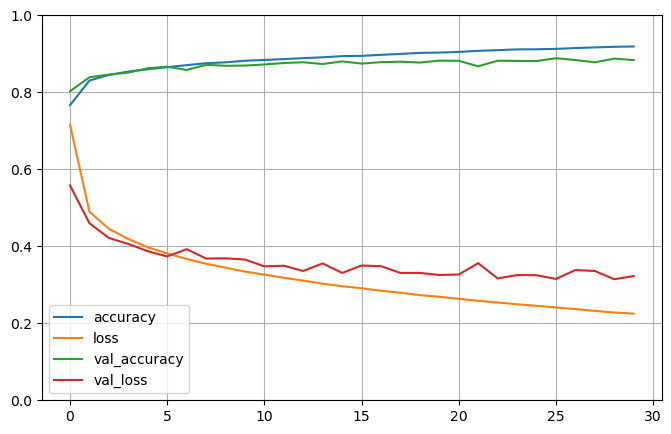

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(model.history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()


In [38]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - accuracy: 0.8683 - loss: 52.7464


[55.301605224609375, 0.8650000095367432]